In [42]:
import json
import matplotlib.pyplot as plt

# CPU Costs
In this experiment, I tested how different values of cpu_tuple_cost, cpu_index_tuple_cost and cpu_operator_cost affect the DB performance.
Their default values are 0.01, 0.005 and 0.0025. Plots are labeled by the values of cpu_tuple_cost; in each experiment, cpu_index_tuple_cost was equal to half of the cpu_tuple_cost,
and cpu_operator_cost was equal to half of the cpu_operator_cost. Other parameters had default values.

## Parse SSD results

In [43]:
with open('data/results_ssd_cpu.jsonl', 'r', encoding='utf-8') as f:
    ssd_json = json.load(f)

ssd_tp = []
ssd_gtp = []
ssd_ctc = []
ssd_dist = []

for entry in ssd_json:
    ssd_tp.append(entry['Throughput (requests/second)'])
    ssd_gtp.append(entry['Goodput (requests/second)'])
    ssd_ctc.append(float(entry['cpu_tuple_cost'][0]))
    ssd_dist.append({
        'med': entry['Latency Distribution']['Median Latency (microseconds)'],
        'q1': entry['Latency Distribution']['25th Percentile Latency (microseconds)'],
        'q3': entry['Latency Distribution']['75th Percentile Latency (microseconds)'],
        'whislo': entry['Latency Distribution']['Minimum Latency (microseconds)'],
        'whishi': entry['Latency Distribution']['Maximum Latency (microseconds)'],
        'mean': entry['Latency Distribution']['Average Latency (microseconds)'],
    })

## Parse HDD results

In [44]:
with open('data/results_hdd_cpu.jsonl', 'r', encoding='utf-8') as f:
    hdd_json = json.load(f)

hdd_tp = []
hdd_gtp = []
hdd_ctc = []
hdd_dist = []

for entry in hdd_json:
    hdd_tp.append(entry['Throughput (requests/second)'])
    hdd_gtp.append(entry['Goodput (requests/second)'])
    hdd_ctc.append(float(entry['cpu_tuple_cost'][0]))
    hdd_dist.append({
        'med': entry['Latency Distribution']['Median Latency (microseconds)'],
        'q1': entry['Latency Distribution']['25th Percentile Latency (microseconds)'],
        'q3': entry['Latency Distribution']['75th Percentile Latency (microseconds)'],
        'whislo': entry['Latency Distribution']['Minimum Latency (microseconds)'],
        'whishi': entry['Latency Distribution']['Maximum Latency (microseconds)'],
        'mean': entry['Latency Distribution']['Average Latency (microseconds)'],
    })

## General comparison

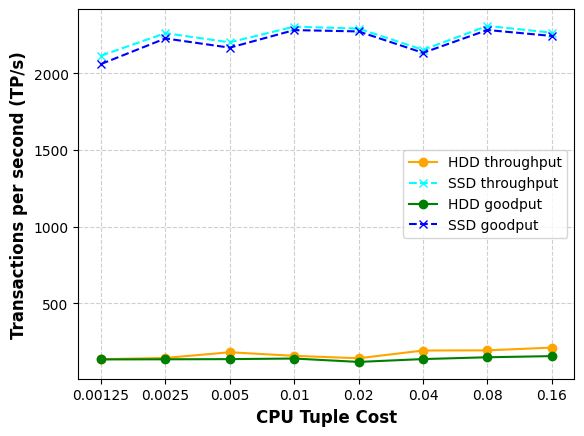

In [45]:
assert(hdd_ctc == hdd_ctc)

fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(hdd_ctc, hdd_tp, label='HDD throughput', color='orange', marker='o')
ax.plot(ssd_ctc, ssd_tp, label='SSD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(hdd_ctc, hdd_gtp, label='HDD goodput', color='green', marker='o')
ax.plot(ssd_ctc, ssd_gtp, label='SSD goodput', color='blue', linestyle='--', marker='x')

ax.set_xscale('log', base=2)
ax.set_xticks(ssd_ctc)
ax.set_xticklabels(ssd_ctc)

ax.set_xlabel('CPU Tuple Cost', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## Detailed SSD throughput vs goodput

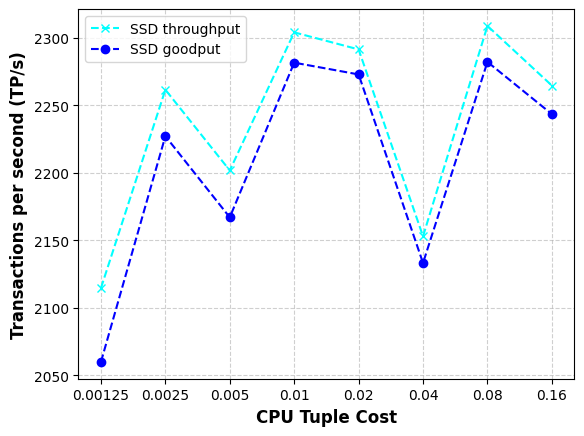

In [46]:
fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(ssd_ctc, ssd_tp, label='SSD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(ssd_ctc, ssd_gtp, label='SSD goodput', color='blue', linestyle='--', marker='o')

ax.set_xscale('log', base=2)
ax.set_xticks(ssd_ctc)
ax.set_xticklabels(ssd_ctc)

ax.set_xlabel('CPU Tuple Cost', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## Detailed HDD throughput vs goodput

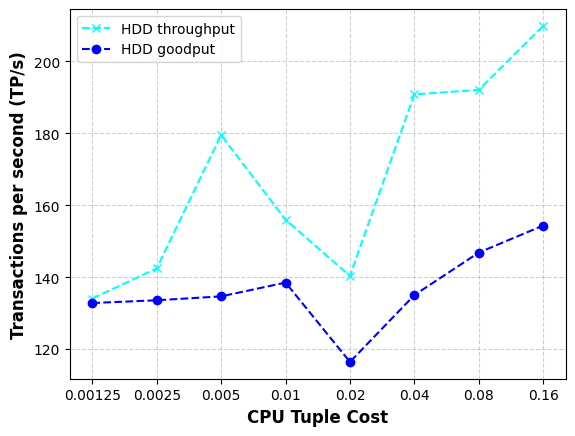

In [47]:
fig, ax = plt.subplots()
ax.grid(True, linestyle='--', alpha=0.6)

ax.plot(hdd_ctc, hdd_tp, label='HDD throughput', color='cyan', linestyle='--', marker='x')
ax.plot(hdd_ctc, hdd_gtp, label='HDD goodput', color='blue', linestyle='--', marker='o')

ax.set_xscale('log', base=2)
ax.set_xticks(hdd_ctc)
ax.set_xticklabels(hdd_ctc)

ax.set_xlabel('CPU Tuple Cost', fontsize=12, fontweight='bold')
ax.set_ylabel('Transactions per second (TP/s)', fontsize=12, fontweight='bold')

ax.legend()
plt.show()

## SSD Latency distribution

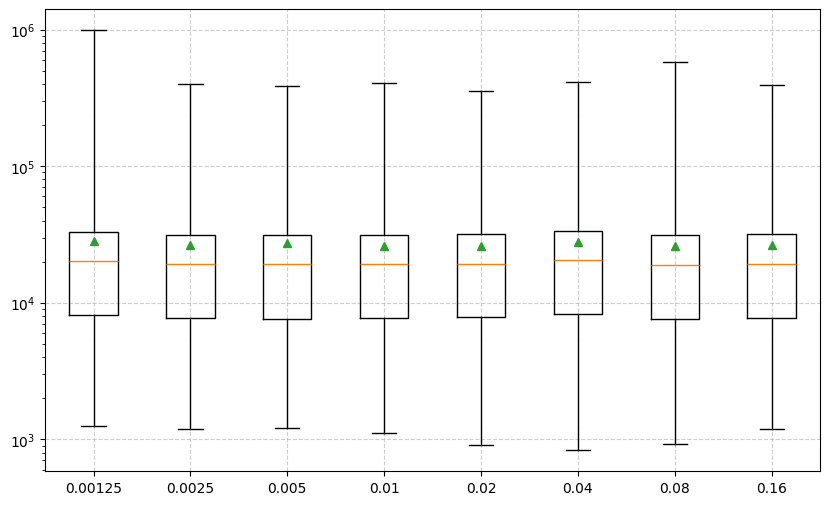

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
integer_positions = range(len(ssd_ctc))
ax.bxp(ssd_dist, positions=integer_positions, widths=0.5, showfliers=False, showmeans=True)

ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.6)

ax.set_xticks(integer_positions)
ax.set_xticklabels(ssd_ctc)
plt.show()

## HDD Latency Distribution

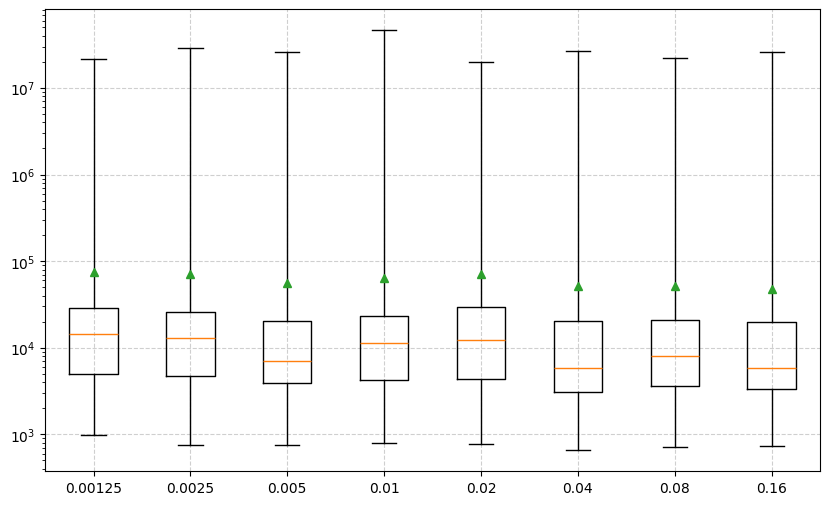

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
integer_positions = range(len(hdd_ctc))
ax.bxp(hdd_dist, positions=integer_positions, widths=0.5, showfliers=False, showmeans=True)

ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.6)

ax.set_xticks(integer_positions)
ax.set_xticklabels(hdd_ctc)
plt.show()